# Decision Tree Grid Search
## An Applied Machine Learning Project 
## by Sean Fletcher

## About Project

The main purpose of this project is to create and visualize a Decision Tree along with sweeping a problem's parameter space - in this case by performing a grid search.  Doing so will allow us to identify the optimal hyperparameter values to be used for training the model.

## Preliminaries

Let's import packages:

In [3]:
import numpy as np
from sklearn import datasets

## Iris Data Set

As described in their user guide, "the famous Iris database, first used by Sir R.A. Fisher. The dataset is taken from Fisher’s paper. Note that it’s the same as in R, but not as in the UCI Machine Learning Repository, which has two wrong data points.

This is perhaps the best known database to be found in the pattern recognition literature. Fisher’s paper is a classic in the field and is referenced frequently to this day. (See Duda & Hart, for example.) The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other."

### About Dataset
Classes : 3
Samples per class: 50
Samples total: 150
Dimensionality: 4
Features: real, positive

Loaded the the `datasets` library from `sklearn` and named the dictionary that is returned `iris`. 

Called train_test_split with a `test_size` of 40% and a `random_state` of `0`.  Output saved to `X_train`, `X_test`, `y_train`, and `y_test`, respectively. 

In [6]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data[:,2:]
y = iris.target

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=0)

In [10]:
X_train, X

(array([[4.5, 1.6],
        [1.6, 0.2],
        [5.1, 1.9],
        [4.2, 1.3],
        [3.6, 1.3],
        [4. , 1.3],
        [4.6, 1.4],
        [6. , 1.8],
        [1.5, 0.2],
        [1.1, 0.1],
        [5.3, 1.9],
        [4.2, 1.2],
        [1.7, 0.2],
        [1.5, 0.4],
        [4.9, 1.5],
        [1.5, 0.2],
        [5.1, 1.8],
        [3. , 1.1],
        [1.4, 0.3],
        [4.5, 1.5],
        [6.1, 2.5],
        [4.2, 1.3],
        [1.4, 0.1],
        [5.9, 2.1],
        [5.7, 2.3],
        [5.8, 2.2],
        [5.6, 2.1],
        [1.6, 0.2],
        [1.6, 0.2],
        [5.1, 2. ],
        [5.7, 2.1],
        [1.3, 0.3],
        [5.4, 2.3],
        [1.4, 0.2],
        [5. , 2. ],
        [5.4, 2.1],
        [1.3, 0.2],
        [1.4, 0.2],
        [5.8, 1.6],
        [1.4, 0.3],
        [1.3, 0.2],
        [1.7, 0.4],
        [4. , 1.3],
        [5.9, 2.3],
        [6.6, 2.1],
        [1.4, 0.2],
        [1.5, 0.2],
        [1.4, 0.2],
        [4.5, 1.3],
        [4.4, 1.4],


## Fitting Decision Tree Classifier

Imported the `DecisionTreeClassifier` class from the `sklearn.tree` library
Created a DecisionTreeClassifier object called `tree_clf` with a `random_state` of `42`
Fitted the DecisionTreeClassifier object on the training data.

In [17]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state = 42)
tree_clf.fit(X, y)

DecisionTreeClassifier(random_state=42)

## Prediction

Made a prediction on the test data, and named the predicted values output by the model `preds`.
Computed the performance of the model by measuring the accuracy score on the test set.   

In [20]:
from sklearn.metrics import accuracy_score
preds =  tree_clf.predict(X)
acc_score = accuracy_score(y, preds)
print('Accuracy=%s' % (acc_score))

Accuracy=0.9933333333333333


## Grid Search

Imported the `GridSearchCV` class from the `sklearn.model_selection` library.
Created a dictionary called `param_grid` with three key-value pairs.  The keys are `max_depth`, `max_leaf_nodes` and `min_samples_split`, and their respective values are `[2,3,4,5,8,16,32]`, `list(range(2, 20, 1))` and `[2,3,4,5,8,12,16,20]`.
Instantiated an object of the `GridSearchCV` class called `grid_search_cv`.  Passed the following as input to the constructor: 
    - The model to be used. Use a `DecisionTreeClassifier` with a `random_state` parameter of `42`.
    - The paramter grid. 
    - The hyperparameter `verbose=1`. (Look this up.)
    - The number of cross-folds. Specify `cv=3`.
    
Called the `fit()` method to perform the grid search using 3-fold cross-validation.
Printed the best parameters identified by the grid search using the `best_params_` attribute of the GridSearchCV object.

In [23]:
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': [2,3,4,5,8,16,32], 'max_leaf_nodes': list(range(2, 20, 1)), 'min_samples_split': [2,3,4,5,8,12,16,20]}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state = 42), param_grid, verbose = 1, cv = 3)
grid_search_cv.fit(X_train, y_train)
print("The best parameters are: ", grid_search_cv.best_params_)

Fitting 3 folds for each of 1008 candidates, totalling 3024 fits
The best parameters are:  {'max_depth': 2, 'max_leaf_nodes': 3, 'min_samples_split': 2}


## Recalculated accuracy

Computed the predicted values `y_pred` using the test set `X_test`.
Calculated the accuracy, precision, and recalled scores using the `accuracy_score()`, `precision_score()`, and `recall_score()` functions.  Called these `acc_score`, `prec_score`, and `recall_score`, respectively. 
Set the average parameter to `micro` when calculating precision and recall to account for multiple classes.
Printed all three scores to the screen.

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
tree_clf_pred = DecisionTreeClassifier(random_state = 42, max_depth = 2, max_leaf_nodes = 3, min_samples_split = 2)
tree_clf_pred.fit(X_test, y_test)
y_pred = tree_clf_pred.predict(X_test)  
acc_score = accuracy_score(y_test, y_pred)
prec_score = precision_score(y_test, y_pred, average = 'micro')
recall_score = recall_score(y_test, y_pred, average = 'micro')
print('Accuracy=%s' % (acc_score))
print('Precision=%s' % (prec_score))
print('Recall=%s' % (recall_score))

Accuracy=0.95
Precision=0.95
Recall=0.95


## Visualize Optimal Decision Tree as Text

Instantiate a new `DecisionTreeClassifier` object, and use the `best_params_` attribute of the `grid_search_cv` object to specify the best `max_depth`, `max_leaf_nodes` and `min_samples_split` values calculated from the grid search along with a `random_state` of `42`.  Retrain the "optimal" (for the few parameters that we swept) decision tree.

Next, use the [tree.export_text()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html) method to visualize the "optimal" decision tree.  This function takes a trained classifier as its first parameter, and a set of feature names as its second parameter (the feature names are included in the `iris` dictionary returned from the `load_iris()` function).  The result is a text based visualization of the decision tree.  Note that this method returns a string, so you'll want to `print()` the result to get it to look right.

In [29]:
from sklearn.tree import export_text
tree_clf_optimal = DecisionTreeClassifier(random_state = 42, max_depth = 2, max_leaf_nodes = 3, min_samples_split = 2)
tree_clf_optimal.fit(X, y)
optimal = export_text(tree_clf_optimal, feature_names = iris['feature_names'][2:])
print(optimal)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



## Visual of Optimal Decision Tree as Image

Used the `tree.plot_tree()` method to visualize the "optimal" decision tree, which takes a trained classifier as its only parameter and returns a graphical visualization of the decision tree. Used `filled=True` as an argument to the method to add color to the image.

[Text(0.4, 0.8333333333333334, 'x[0] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]')]

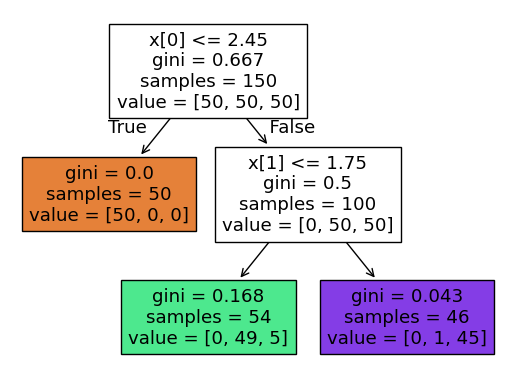

In [32]:
from sklearn import tree
tree.plot_tree(tree_clf_optimal, filled=True)

## Discussion of Decision Tree

1. The hyperparameter verbose determines the amount of information that will be seen in the output message. When set to 1, the output displays only "the computation time for each fold and the parameter candidate". Set to 2, the output also displays the score. Set to three, the "fold and candidate parameter indexes are also displayed". (cited from scikit-learn information page: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

2. The *gini* attribute refers to the impurity of a node. Looking at the number of instances of each class, a node is considered pure (gini = 0) if all of its training instances fit the same class. If the training instances are split between classes than the node is considered impure. The gini attribute demonstrates the amount of impurtity by calculating a score determined by squaring the ratio of each of the class' instances over the totatl number of training instances, then subtracting them from 1. This value reflects the distribution of instances across available nodes.

If a node has a gini value of 0, all instances belong to that class, and there will be no child nodes. If the gini value is greater than 0, the node is impure and the instances may be further distributed again with another decision boundary, creating more child nodes. The amount of child nodes is determined on the purity of the remaining nodes and the setting of the max_depth hyperparameter. 

This method differs from the *entropy* impurity measure. Entropy is also a measure of impurity similiar to gini, where a value of zero represents a node where all classes are identical. Anything greater than zero is considered impure. The entropy measure differs from that of gini in the algarithm used. Entropy uses a logarithmic algorithm. In most cases the decision trees will be the same. However with larger data sets, gini will be faster, but entropy will generally have more balanced trees since it doesn't fave the most frequent class like the gini algorithm does. (Cited from text book: Hands on Machine Learning with Scikit-Learn, Keras, and TensorFlow by Aurelien Geron)

The gini impurity measure uses the CART (Classification and Regression Tree) algorithm to train decision trees. The CART algorithm is a supervised learinng algorithm that uses the gini impurity test to determine the splits in the decision tree by deteriming which instance will minimize the gini impurity of the resultant subsets. This splitting will continue until maximum tree depth is reach or the number of instances in a leaf node is at a minimum. 

The CART algorithm will then use regression trees to predict values of continuous variables. It does this by evaluationg the amount of reduction in the average squared differenct between predicted values and actual values for the target variables. How well the model fits actual values is determined by the amount of residual reduction found in the target variables. The better the fit the closer the predicted values are to the actual values. This reduction of residual error will determine splits at each node by choosing the split that results in the maximum reduction in the subsets. Like the classification tree, splitting will continue until maximum tree depth is reached or there is a minimum number of instances. (Cited from webpage: https://www.geeksforgeeks.org/cart-classification-and-regression-tree-in-machine-learning/)

## Critical Analysis

The accuracy score without the grid search was 0.993. After the grid search the accuracy decreased to 0.95. I did expect an improvement in accuracy, since the optimal hyperparameters were used. The accuracy decreased for the test set, because the set was tuned to the validation data. The test data may not tune as well with the hyperparameters, since it is a smaller set. This does not mean that they hyperparameter are not preferable. Since they are tuned to a larger set, they are more likely to generalize to new data. (Cited from text book: Hands on Machine Learning with Scikit-Learn, Keras, and TensorFlow by Aurelien Geron)